# Fixture-Proof Teams — Playground #6

Which teams beat **everyone**, and which only feast on the weak? We split each team's season
by **opponent tier** (top-6 / mid-8 / bottom-6 of the final table) and compare **points**,
**goals scored**, and **goals conceded** per game. Team-level sibling of #05
([spec 13](../../brainstorming/13-team-fixture-proof.md)).

**CS problem:** *stratified aggregation + a group-difference test*. Build `team × bucket`
matrices (concept E) and read the **gradient** (bottom-tier − top-tier). The league table
ranks by *total* points; the gradient reveals *how* they were earned — a title team is flat
(beats everyone), a flat-track-bully team is steep (fat vs the bottom-6, folds vs the top-6).

**Method**
1. Derive the final table from results → opponent tier map.
2. Explode fixtures into per-team rows: points (3/1/0), goals-for, goals-against, opp tier, venue.
3. **Axis A — opponent tier:** per-game PPG / GF / GA by tier; gradients; heatmaps + scatter.
4. **Axis B — venue:** same metrics split home vs away; gradients + scatter.
5. Master table combining both axes.

## Config — edit me

In [1]:
SEASON = "2025-26"
BASE = f"https://raw.githubusercontent.com/vaastav/Fantasy-Premier-League/master/data/{SEASON}"
FIXTURES_URL = f"{BASE}/fixtures.csv"
TEAMS_URL    = f"{BASE}/teams.csv"

# Tier sizes over the final table (must sum to 20).
TOP_N, MID_N, BOT_N = 6, 8, 6


## Fetch + final table → opponent tiers

Same derivation as #05: `teams.csv` positions are a pre-season snapshot, so we build the real standings from finished results.

In [2]:
import io, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def read_csv(url):
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    return pd.read_csv(io.BytesIO(urllib.request.urlopen(req, timeout=60).read()))

fixtures = read_csv(FIXTURES_URL)
teams    = read_csv(TEAMS_URL)
team_name = dict(zip(teams["id"], teams["short_name"]))

fin = fixtures[(fixtures["finished"] == True) & fixtures["team_h_score"].notna()].copy()
fin["team_h_score"] = fin["team_h_score"].astype(int)
fin["team_a_score"] = fin["team_a_score"].astype(int)

rows = []
for _, f in fin.iterrows():
    hs, as_ = f["team_h_score"], f["team_a_score"]
    hp, ap = (3, 0) if hs > as_ else (0, 3) if hs < as_ else (1, 1)
    rows.append((f["team_h"], hp, hs - as_))
    rows.append((f["team_a"], ap, as_ - hs))
standings = (pd.DataFrame(rows, columns=["team", "pts", "gd"])
             .groupby("team").agg(pts=("pts", "sum"), gd=("gd", "sum"))
             .sort_values(["pts", "gd"], ascending=False).reset_index())
standings["position"] = np.arange(1, len(standings) + 1)
standings["short"] = standings["team"].map(team_name)

def tier_of(pos):
    if pos <= TOP_N: return "top"
    if pos <= TOP_N + MID_N: return "mid"
    return "bot"
standings["tier"] = standings["position"].map(tier_of)
opp_tier = dict(zip(standings["team"], standings["tier"]))
team_pos = dict(zip(standings["team"], standings["position"]))
print(f"{len(fin)} finished matches, {SEASON}")
print(standings[["position", "short", "pts", "gd", "tier"]].to_string(index=False))


380 finished matches, 2025-26
 position short  pts  gd tier
        1   ARS   85  44  top
        2   MCI   78  42  top
        3   MUN   71  19  top
        4   AVL   65   7  top
        5   LIV   60  10  top
        6   BOU   57   4  top
        7   SUN   54  -6  mid
        8   BHA   53   6  mid
        9   BRE   53   3  mid
       10   CHE   52   6  mid
       11   FUL   52  -4  mid
       12   NEW   49  -2  mid
       13   EVE   49  -3  mid
       14   LEE   47  -7  mid
       15   CRY   45 -10  bot
       16   NFO   44  -3  bot
       17   TOT   41  -9  bot
       18   WHU   39 -19  bot
       19   BUR   22 -37  bot
       20   WOL   20 -41  bot


## Explode fixtures into per-team rows

Each match → two rows (one per team), carrying that team's points, goals-for, goals-against and the **opponent's** tier.

In [3]:
recs = []
for _, f in fin.iterrows():
    h, a = f["team_h"], f["team_a"]
    hs, as_ = f["team_h_score"], f["team_a_score"]
    hp, ap = (3, 0) if hs > as_ else (0, 3) if hs < as_ else (1, 1)
    recs.append((h, opp_tier[a], "home", hp, hs, as_))   # home team, opponent = a
    recs.append((a, opp_tier[h], "away", ap, as_, hs))   # away team, opponent = h
tm = pd.DataFrame(recs, columns=["team", "opp_tier", "venue", "pts", "gf", "ga"])
tm["short"] = tm["team"].map(team_name)
print(tm.head())


   team opp_tier venue  pts  gf  ga short
0    12      top  home    3   4   2   LIV
1     4      top  away    0   2   4   BOU
2     2      mid  home    1   0   0   AVL
3    15      top  away    1   0   0   NEW
4     6      mid  home    1   1   1   BHA


## The team × tier engine

Per `(team, tier)`: matches played and **per-game** points / goals-for / goals-against.

In [4]:
tier_order = ["top", "mid", "bot"]

def by_tier(metric):
    """team × tier matrix of per-game `metric` (mean over that tier's matches)."""
    m = (tm.groupby(["short", "opp_tier"])[metric].mean()
         .unstack("opp_tier").reindex(columns=tier_order))
    return m

games = (tm.groupby(["short", "opp_tier"]).size().unstack("opp_tier").reindex(columns=tier_order))
ppg = by_tier("pts"); gf = by_tier("gf"); ga = by_tier("ga")

overall = tm.groupby("short").agg(ppg=("pts", "mean"), gf=("gf", "mean"), ga=("ga", "mean"))
overall["position"] = overall.index.map({team_name[t]: p for t, p in team_pos.items()})
print("games per tier (should be ~10-12 each):")
print(games.round(0).astype(int))


games per tier (should be ~10-12 each):
opp_tier  top  mid  bot
short                  
ARS        10   16   12
AVL        10   16   12
BHA        12   14   12
BOU        10   16   12
BRE        12   14   12
BUR        12   16   10
CHE        12   14   12
CRY        12   16   10
EVE        12   14   12
FUL        12   14   12
LEE        12   14   12
LIV        10   16   12
MCI        10   16   12
MUN        10   16   12
NEW        12   14   12
NFO        12   16   10
SUN        12   14   12
TOT        12   16   10
WHU        12   16   10
WOL        12   16   10


## Points by opponent tier

**points_grad = PPG(bot) − PPG(top).** Flat ≈ fixture-proof (beats everyone); large positive
= flat-track bully (piles points on the weak, folds vs the elite).

In [5]:
pts_tbl = ppg.rename(columns={"top": "vs_top", "mid": "vs_mid", "bot": "vs_bot"}).copy()
pts_tbl["points_grad"] = pts_tbl["vs_bot"] - pts_tbl["vs_top"]
pts_tbl["overall_ppg"] = overall["ppg"]
pts_tbl["position"] = overall["position"]
pts_tbl.sort_values("position")[
    ["position", "vs_top", "vs_mid", "vs_bot", "points_grad", "overall_ppg"]].round(2)


opp_tier,position,vs_top,vs_mid,vs_bot,points_grad,overall_ppg
short,,,,,,
ARS,1,1.10,2.62,2.67,1.57,2.24
MCI,2,1.70,2.12,2.25,0.55,2.05
MUN,3,1.70,1.88,2.00,0.30,1.87
AVL,4,1.90,1.56,1.75,-0.15,1.71
LIV,5,1.00,1.69,1.92,0.92,1.58
BOU,6,1.00,1.44,2.00,1.00,1.50
SUN,7,0.75,1.71,1.75,1.00,1.42
BHA,8,0.67,1.71,1.75,1.08,1.39
BRE,9,1.50,1.21,1.50,0.00,1.39


## Goals for & against by opponent tier

In [6]:
goals = gf.rename(columns={"top": "gf_top", "mid": "gf_mid", "bot": "gf_bot"}).copy()
goals["gf_grad"] = goals["gf_bot"] - goals["gf_top"]
ga_r = ga.rename(columns={"top": "ga_top", "mid": "ga_mid", "bot": "ga_bot"})
goals = goals.join(ga_r)
# ga_grad = GA(top) - GA(bot): positive = leakier against the elite (the expected direction);
# near 0 = defends the top-6 as well as anyone (fixture-proof defence).
goals["ga_grad"] = goals["ga_top"] - goals["ga_bot"]
goals["position"] = overall["position"]
goals.sort_values("position")[
    ["position", "gf_top", "gf_mid", "gf_bot", "gf_grad",
     "ga_top", "ga_mid", "ga_bot", "ga_grad"]].round(2)


opp_tier,position,gf_top,gf_mid,gf_bot,gf_grad,ga_top,ga_mid,ga_bot,ga_grad
short,,,,,,,,,
ARS,1,1.40,2.06,2.00,0.60,1.40,0.44,0.50,0.90
MCI,2,1.60,2.06,2.33,0.73,1.00,1.00,0.75,0.25
MUN,3,2.00,1.50,2.08,0.08,1.80,1.00,1.33,0.47
AVL,4,1.80,1.31,1.42,-0.38,1.50,1.19,1.25,0.25
LIV,5,1.50,1.75,1.67,0.17,1.90,1.25,1.17,0.73
BOU,6,1.80,1.31,1.58,-0.22,2.50,1.25,0.75,1.75
SUN,7,0.92,1.14,1.25,0.33,1.67,1.07,1.08,0.58
BHA,8,1.08,1.43,1.58,0.50,1.92,0.93,0.83,1.08
BRE,9,1.25,1.50,1.58,0.33,1.17,1.50,1.42,-0.25


## Heatmaps — per-game metric by tier (ordered by final position)

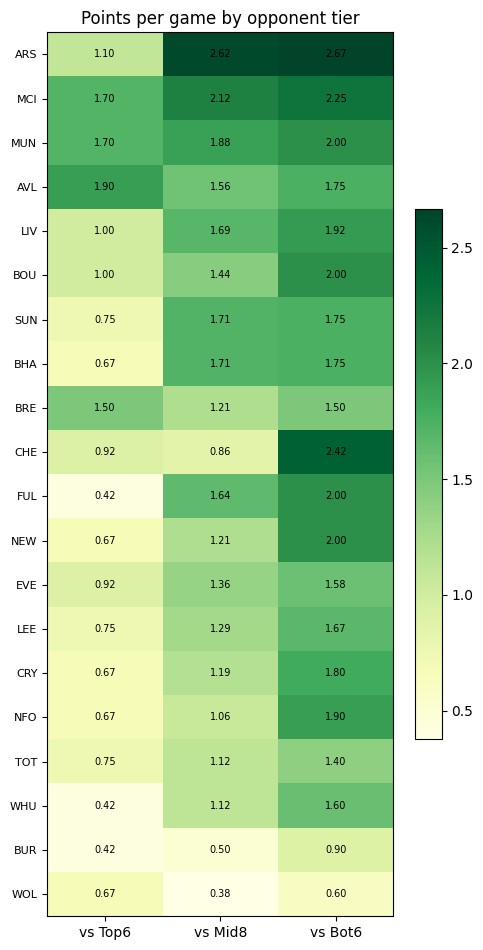

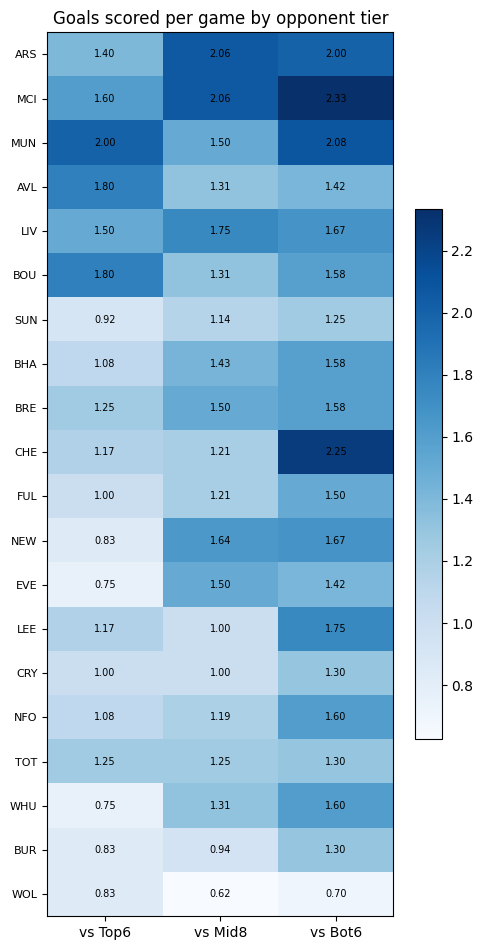

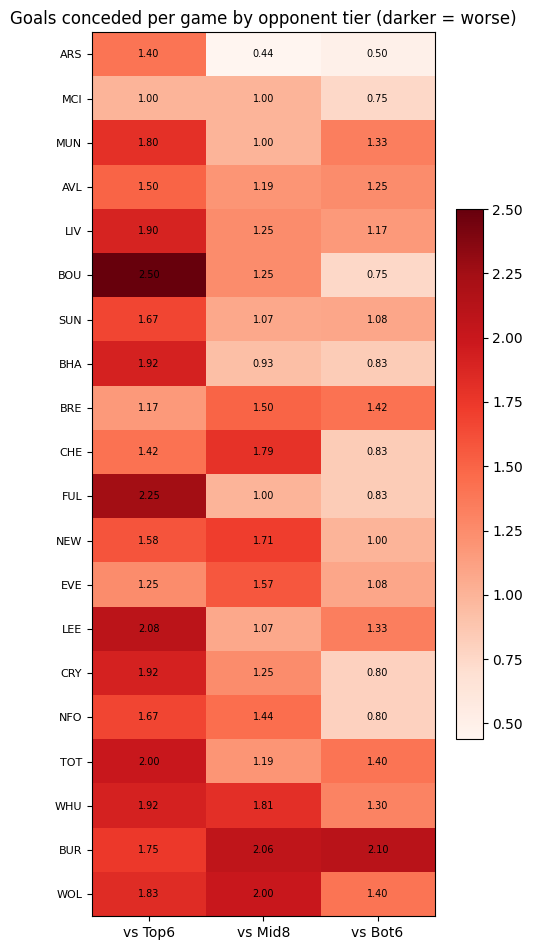

In [7]:
def heatmap(mat, title, cmap, fmt="{:.2f}"):
    order = overall.sort_values("position").index
    M = mat.reindex(order)[tier_order].values.astype(float)
    fig, ax = plt.subplots(figsize=(5, 0.42 * len(order) + 1.2))
    im = ax.imshow(M, aspect="auto", cmap=cmap)
    ax.set_xticks(range(3)); ax.set_xticklabels(["vs Top6", "vs Mid8", "vs Bot6"])
    ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=8)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, fmt.format(M[i, j]), ha="center", va="center", fontsize=7)
    ax.set_title(title); fig.colorbar(im, ax=ax, shrink=0.6)
    plt.tight_layout(); plt.show()

heatmap(ppg, "Points per game by opponent tier", "YlGn")
heatmap(gf, "Goals scored per game by opponent tier", "Blues")
heatmap(ga, "Goals conceded per game by opponent tier (darker = worse)", "Reds")


## Money shot — overall PPG vs points gradient

**Top-left** (high PPG, flat gradient) = genuine contenders who beat everyone. **Top-right**
(decent PPG, steep gradient) = flat-track-bully teams whose points came against weak sides.

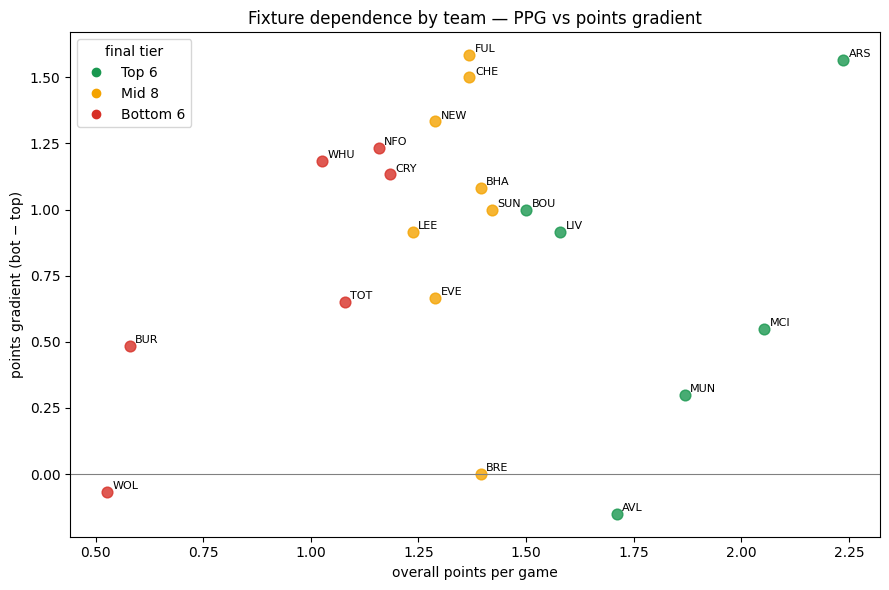

In [8]:
d = pts_tbl.dropna(subset=["points_grad", "overall_ppg"])
fig, ax = plt.subplots(figsize=(9, 6))
colors = {"top": "#1a9850", "mid": "#f4a300", "bot": "#d73027"}
tiers = overall.index.map(lambda s: opp_tier[[t for t, n in team_name.items() if n == s][0]])
for s, r in d.iterrows():
    t = tier_of(int(r["position"]))
    ax.scatter(r["overall_ppg"], r["points_grad"], s=60, color=colors[t], alpha=0.8)
    ax.annotate(s, (r["overall_ppg"], r["points_grad"]), fontsize=8,
                xytext=(4, 2), textcoords="offset points")
ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("overall points per game"); ax.set_ylabel("points gradient (bot − top)")
ax.set_title("Fixture dependence by team — PPG vs points gradient")
handles = [plt.Line2D([0], [0], marker="o", ls="", color=colors[k],
           label={"top": "Top 6", "mid": "Mid 8", "bot": "Bottom 6"}[k]) for k in tier_order]
ax.legend(handles=handles, title="final tier")
plt.tight_layout(); plt.show()


## Axis B — venue (home / away)

Same engine, second axis: split each team's results by **venue** instead of opponent tier.
**Gradient = per-game(home) − per-game(away).** Flat ≈ venue-proof; large positive points
gradient = a fortress-at-home / soft-away team.

In [9]:
venue_order = ["home", "away"]

def by_venue(metric):
    """team × venue matrix of per-game `metric`."""
    return (tm.groupby(["short", "venue"])[metric].mean()
            .unstack("venue").reindex(columns=venue_order))

vppg, vgf, vga = by_venue("pts"), by_venue("gf"), by_venue("ga")

ven = pd.DataFrame({
    "position":   overall["position"],
    "ppg_home":   vppg["home"], "ppg_away": vppg["away"],
    "pts_grad":   vppg["home"] - vppg["away"],
    "gf_home":    vgf["home"],  "gf_away":  vgf["away"],
    "gf_grad":    vgf["home"]  - vgf["away"],
    "ga_home":    vga["home"],  "ga_away":  vga["away"],
    # ga_grad = GA(away) - GA(home): positive = leakier on the road (expected); ~0 = travels well.
    "ga_grad":    vga["away"]  - vga["home"],
})
ven.sort_values("position")[
    ["position", "ppg_home", "ppg_away", "pts_grad",
     "gf_grad", "ga_grad"]].round(2)


,position,ppg_home,ppg_away,pts_grad,gf_grad,ga_grad
short,,,,,,
ARS,1,2.47,2.00,0.47,0.58,0.26
MCI,2,2.37,1.74,0.63,0.68,0.37
MUN,3,2.21,1.53,0.68,0.47,0.11
AVL,4,2.00,1.42,0.58,0.42,0.26
LIV,5,1.89,1.26,0.63,0.26,0.68
BOU,6,1.63,1.37,0.26,0.00,0.74
SUN,7,1.74,1.11,0.63,0.42,0.42
BHA,8,1.74,1.05,0.68,0.42,0.32
BRE,9,1.68,1.11,0.58,0.58,0.53


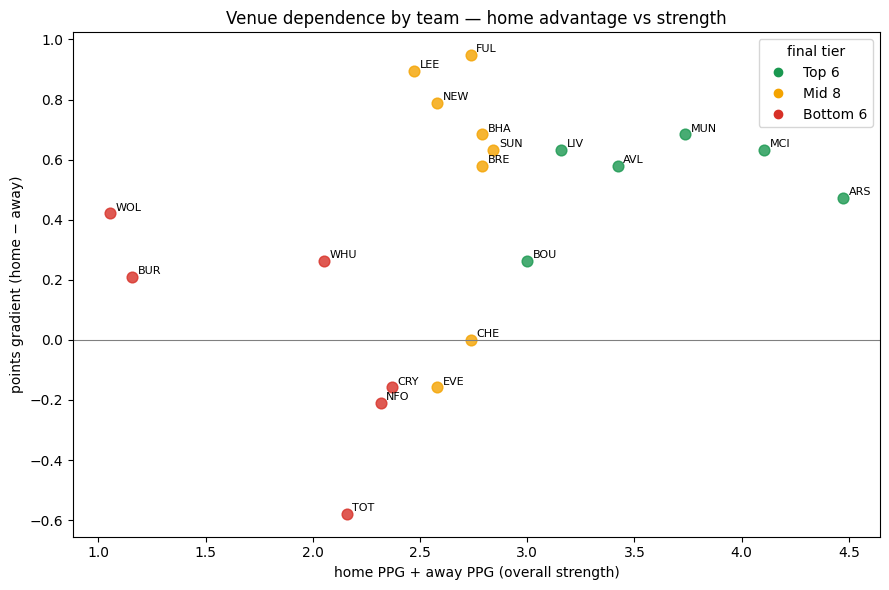

In [10]:
d = ven.dropna(subset=["pts_grad"])
fig, ax = plt.subplots(figsize=(9, 6))
colors = {"top": "#1a9850", "mid": "#f4a300", "bot": "#d73027"}
for s, r in d.iterrows():
    t = tier_of(int(r["position"]))
    ax.scatter(r["ppg_home"] + r["ppg_away"], r["pts_grad"], s=60, color=colors[t], alpha=0.8)
    ax.annotate(s, (r["ppg_home"] + r["ppg_away"], r["pts_grad"]), fontsize=8,
                xytext=(4, 2), textcoords="offset points")
ax.axhline(0, color="grey", lw=0.8)
ax.set_xlabel("home PPG + away PPG (overall strength)")
ax.set_ylabel("points gradient (home − away)")
ax.set_title("Venue dependence by team — home advantage vs strength")
handles = [plt.Line2D([0], [0], marker="o", ls="", color=colors[k],
           label={"top": "Top 6", "mid": "Mid 8", "bot": "Bottom 6"}[k]) for k in tier_order]
ax.legend(handles=handles, title="final tier")
plt.tight_layout(); plt.show()


### Heatmaps — per-game metric by venue (ordered by final position)

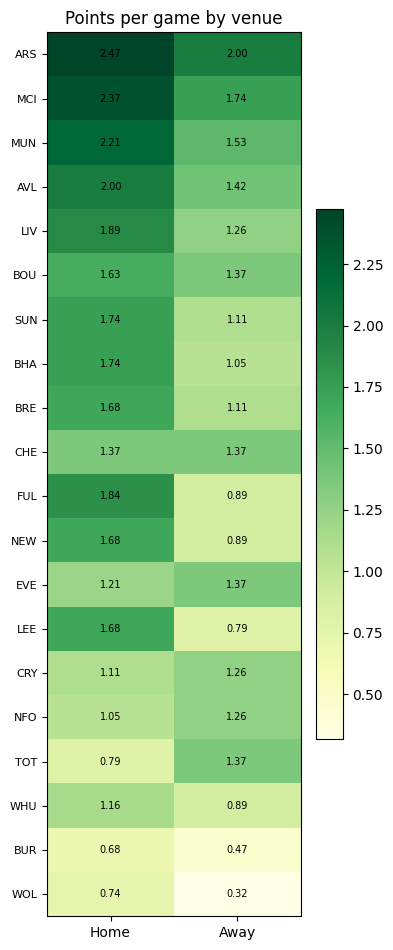

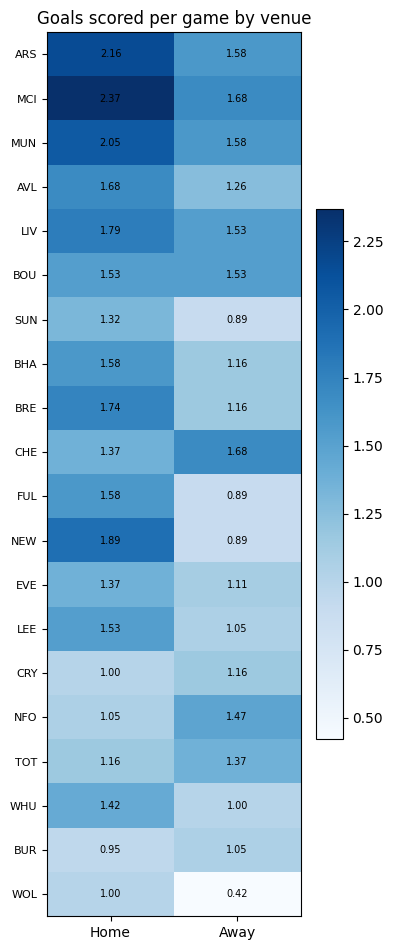

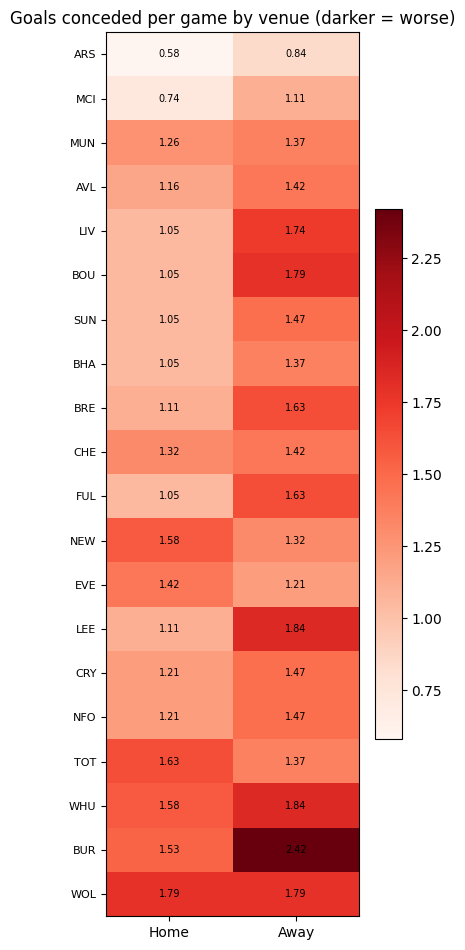

In [11]:
def heatmap_venue(mat, title, cmap, fmt="{:.2f}"):
    order = overall.sort_values("position").index
    M = mat.reindex(order)[venue_order].values.astype(float)
    fig, ax = plt.subplots(figsize=(4, 0.42 * len(order) + 1.2))
    im = ax.imshow(M, aspect="auto", cmap=cmap)
    ax.set_xticks(range(2)); ax.set_xticklabels(["Home", "Away"])
    ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=8)
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, fmt.format(M[i, j]), ha="center", va="center", fontsize=7)
    ax.set_title(title); fig.colorbar(im, ax=ax, shrink=0.6)
    plt.tight_layout(); plt.show()

heatmap_venue(vppg, "Points per game by venue", "YlGn")
heatmap_venue(vgf, "Goals scored per game by venue", "Blues")
heatmap_venue(vga, "Goals conceded per game by venue (darker = worse)", "Reds")


## Master table — teams ranked by fixture-proofness

All metrics + gradients in one place, across **both axes**. `points_grad ≈ 0` with high
`overall_ppg` is the fixture-proof contender; `venue_pts_grad` is the home−away swing; a low
`ga_grad` means the defence held up against the elite too.

In [12]:
master = pts_tbl[["position", "overall_ppg", "points_grad"]].join(
    goals[["gf_grad", "ga_grad"]])
master["venue_pts_grad"] = ven["pts_grad"]
master["gf_overall"] = overall["gf"]
master["ga_overall"] = overall["ga"]
master.sort_values(["points_grad"])[
    ["position", "overall_ppg", "points_grad", "venue_pts_grad",
     "gf_overall", "gf_grad", "ga_overall", "ga_grad"]].round(2)


opp_tier,position,overall_ppg,points_grad,venue_pts_grad,gf_overall,gf_grad,ga_overall,ga_grad
short,,,,,,,,
AVL,4,1.71,-0.15,0.58,1.47,-0.38,1.29,0.25
WOL,20,0.53,-0.07,0.42,0.71,-0.13,1.79,0.43
BRE,9,1.39,0.00,0.58,1.45,0.33,1.37,-0.25
MUN,3,1.87,0.30,0.68,1.82,0.08,1.32,0.47
BUR,19,0.58,0.48,0.21,1.00,0.47,1.97,-0.35
MCI,2,2.05,0.55,0.63,2.03,0.73,0.92,0.25
TOT,17,1.08,0.65,-0.58,1.26,0.05,1.50,0.60
EVE,13,1.29,0.67,-0.16,1.24,0.67,1.32,0.17
LEE,14,1.24,0.92,0.89,1.29,0.58,1.47,0.75
